In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- Brito (2020) GU 1-4 系数 (Table 2) ----
A0, A1, A2, A3, A4, A5 = 2.707e-1, 1.215e-3, 1.431e-2, 4.112e-5, -8.334e-6, -1.728e-4
D_LOSS = 1.740e-5
W_MIN, W_MAX = 180.0, 301.0     # 流量 w (m3/s)
H_MIN, H_MAX = 65.0, 75.2       # 毛水头 h (m)

def f_true(w, h):
    """Brito HPF: g = 9.81e-3 * eta * (h - D*w^2) * w  [MW]"""
    hn = h - D_LOSS * w**2                      # 净水头
    eta = A0 + A1*w + A2*hn + A3*w*hn + A4*w**2 + A5*hn**2
    return 9.81e-3 * eta * hn * w

# ---- 50 x 50 = 2500 训练采样点 ----
# Cell 1 里替换采样部分：均匀 100 列 + 陡坡区 (d in [0,4]) 额外 50 列
ws = np.sort(np.concatenate([
    np.linspace(W_MIN, W_MAX, 100),
    np.linspace(0.0, 4.0, 50),
]))
hs = np.linspace(H_MIN, H_MAX, 100)
WW, HH = np.meshgrid(ws, hs, indexing="ij")
X_all = np.stack([WW.ravel(), HH.ravel()], axis=1)          # (2500, 2)
y_all = f_true(X_all[:, 0], X_all[:, 1])[:, None]           # (2500, 1)

# 80/20 划分
perm = np.random.permutation(len(X_all))
n_tr = int(0.8 * len(X_all))
tr_idx, te_idx = perm[:n_tr], perm[n_tr:]

# 归一化：输入 -> [0,1]^2，输出标准化
X_lo = np.array([W_MIN, H_MIN]); X_hi = np.array([W_MAX, H_MAX])
y_mu, y_sd = y_all[tr_idx].mean(), y_all[tr_idx].std()

def norm_x(X): return (X - X_lo) / (X_hi - X_lo)

Xtr = torch.tensor(norm_x(X_all[tr_idx]), dtype=torch.float32, device=device)
ytr = torch.tensor((y_all[tr_idx] - y_mu) / y_sd, dtype=torch.float32, device=device)
Xte = torch.tensor(norm_x(X_all[te_idx]), dtype=torch.float32, device=device)
yte = torch.tensor((y_all[te_idx] - y_mu) / y_sd, dtype=torch.float32, device=device)
print("train:", Xtr.shape, "test:", Xte.shape)

device: cuda
train: torch.Size([12000, 2]) test: torch.Size([3000, 2])


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- Heintzmann et al. (2024), Parameter Set B (Small/Shallow), Unit j=1 ----
# 5PL 参数: y_k = alpha_k + beta_k * h
ALPHA = np.array([-0.5, 3.0, 0.8, 0.4, 0.85])          # a1..a5
BETA  = np.array([0.0033, 0.0098, 0.0046, 0.0225, 0.001])  # b1..b5
# 毛水头函数 h(v) = B0 + B1*v + B2*v^B3  (Set B: 100, 0.2, 2, 0.6; 尾水 C 全为 0)
B0, B1_, B2_, B3_ = 100.0, 0.2, 2.0, 0.6
def head_of_v(v): return B0 + B1_*v + B2_*v**B3_

# 定义域: d ∈ [0, 10] m3/s (Set B 的 D_max);  h 取 v ∈ [20, 100] hm3 对应范围
W_MIN, W_MAX = 0.0, 10.0                       # 这里 x1 = 流量 d
H_MIN, H_MAX = head_of_v(20.0), head_of_v(100.0)   # ≈ [116.07, 151.70] m
print(f"h range: [{H_MIN:.2f}, {H_MAX:.2f}] m")

def f_true(d, h):
    """Heintzmann P_ref: p = 9.81e-3 * h * 5PL(d; y(h))  [MW]
       5PL = y4 - y4 / (1 + (max(0, d-y1)/y3)^y2)^y5
    """
    y1 = ALPHA[0] + BETA[0]*h
    y2 = ALPHA[1] + BETA[1]*h
    y3 = ALPHA[2] + BETA[2]*h
    y4 = ALPHA[3] + BETA[3]*h
    y5 = ALPHA[4] + BETA[4]*h
    z = np.maximum(0.0, d - y1) / y3
    pl = y4 - y4 / (1.0 + z**y2)**y5
    return 9.81e-3 * h * pl

# ---- 50 x 50 = 2500 训练采样点 ----
ws = np.linspace(W_MIN, W_MAX, 50)
hs = np.linspace(H_MIN, H_MAX, 50)
WW, HH = np.meshgrid(ws, hs, indexing="ij")
X_all = np.stack([WW.ravel(), HH.ravel()], axis=1)
y_all = f_true(X_all[:, 0], X_all[:, 1])[:, None]
print(f"p range: [{y_all.min():.3f}, {y_all.max():.3f}] MW")

# 80/20 划分
perm = np.random.permutation(len(X_all))
n_tr = int(0.8 * len(X_all))
tr_idx, te_idx = perm[:n_tr], perm[n_tr:]

# 归一化：输入 -> [0,1]^2，输出标准化
X_lo = np.array([W_MIN, H_MIN]); X_hi = np.array([W_MAX, H_MAX])
y_mu, y_sd = y_all[tr_idx].mean(), y_all[tr_idx].std()

def norm_x(X): return (X - X_lo) / (X_hi - X_lo)

Xtr = torch.tensor(norm_x(X_all[tr_idx]), dtype=torch.float32, device=device)
ytr = torch.tensor((y_all[tr_idx] - y_mu) / y_sd, dtype=torch.float32, device=device)
Xte = torch.tensor(norm_x(X_all[te_idx]), dtype=torch.float32, device=device)
yte = torch.tensor((y_all[te_idx] - y_mu) / y_sd, dtype=torch.float32, device=device)
print("train:", Xtr.shape, "test:", Xte.shape)

device: cuda
h range: [116.07, 151.70] m
p range: [0.000, 5.674] MW
train: torch.Size([2000, 2]) test: torch.Size([500, 2])


In [3]:
class ReLUNet(nn.Module):
    def __init__(self, hidden):                 # hidden 例如 [16] 或 [16,16]
        super().__init__()
        dims = [2] + list(hidden) + [1]
        self.linears = nn.ModuleList(nn.Linear(dims[i], dims[i+1])
                                     for i in range(len(dims)-1))
    def forward(self, x, return_pattern=False):
        pats = []
        for i, lin in enumerate(self.linears):
            x = lin(x)
            if i < len(self.linears) - 1:
                if return_pattern:
                    pats.append(x > 0)
                x = torch.relu(x)
        if return_pattern:
            return x, torch.cat(pats, dim=1)    # (N, 总神经元数) bool
        return x

def train_model(hidden, epochs=30000, lr=3e-4, verbose=True):
    model = ReLUNet(hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    for ep in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward(); opt.step(); sched.step()
        if verbose and (ep + 1) % 3000 == 0:
            with torch.no_grad():
                te = loss_fn(model(Xte), yte).item()
            print(f"  hidden={hidden} ep{ep+1}: train={loss.item():.2e} test={te:.2e}")
    return model

In [4]:
# 稠密评估网格（物理单位 MW 下算误差；也用它数区域）
N_DENSE = 400
wd = np.linspace(W_MIN, W_MAX, N_DENSE)
hd = np.linspace(H_MIN, H_MAX, N_DENSE)
WD, HD = np.meshgrid(wd, hd, indexing="ij")
X_dense = np.stack([WD.ravel(), HD.ravel()], axis=1)
y_dense = f_true(X_dense[:, 0], X_dense[:, 1])
X_dense_t = torch.tensor(norm_x(X_dense), dtype=torch.float32, device=device)

@torch.no_grad()
def count_regions(model, batch=200_000):
    """在稠密网格上统计唯一激活模式数（域内区域数的经验计数/下界）"""
    pats = []
    for i in range(0, len(X_dense_t), batch):
        _, p = model(X_dense_t[i:i+batch], return_pattern=True)
        pats.append(p)
    pats = torch.cat(pats, dim=0)
    return torch.unique(pats, dim=0).shape[0]

@torch.no_grad()
def eval_errors(model):
    pred = model(X_dense_t).cpu().numpy().ravel() * y_sd + y_mu   # 反归一化 -> MW
    err = np.abs(pred - y_dense)
    return err.mean(), err.max()

In [5]:
configs = [([n, n], "2-layer") for n in (8, 16, 32, 64, 128)]

relu_results = []   # (label, hidden, regions, MAE, MaxErr)
for hidden, label in configs:
    print(f"training {label} {hidden} ...")
    model = train_model(hidden)
    R = count_regions(model)
    mae, mx = eval_errors(model)
    relu_results.append((label, hidden, R, mae, mx))
    print(f"  -> regions={R}, MAE={mae:.4f} MW, MaxErr={mx:.4f} MW\n")

training 2-layer [8, 8] ...
  hidden=[8, 8] ep3000: train=2.41e-02 test=2.13e-02
  hidden=[8, 8] ep6000: train=3.33e-03 test=2.91e-03
  hidden=[8, 8] ep9000: train=4.39e-04 test=5.11e-04
  hidden=[8, 8] ep12000: train=3.53e-04 test=4.02e-04
  hidden=[8, 8] ep15000: train=2.96e-04 test=3.33e-04
  hidden=[8, 8] ep18000: train=2.65e-04 test=3.05e-04
  hidden=[8, 8] ep21000: train=2.61e-04 test=2.99e-04
  hidden=[8, 8] ep24000: train=2.61e-04 test=3.00e-04
  hidden=[8, 8] ep27000: train=2.60e-04 test=2.98e-04
  hidden=[8, 8] ep30000: train=2.60e-04 test=2.98e-04
  -> regions=9, MAE=0.0202 MW, MaxErr=0.1208 MW

training 2-layer [16, 16] ...
  hidden=[16, 16] ep3000: train=1.04e-02 test=8.89e-03
  hidden=[16, 16] ep6000: train=4.05e-03 test=3.43e-03
  hidden=[16, 16] ep9000: train=1.07e-03 test=9.74e-04
  hidden=[16, 16] ep12000: train=4.43e-04 test=4.03e-04
  hidden=[16, 16] ep15000: train=2.49e-04 test=2.28e-04
  hidden=[16, 16] ep18000: train=1.23e-04 test=9.53e-05
  hidden=[16, 16] ep210

In [6]:
mesh_results = []   # (K, triangles, MAE, MaxErr)
for K in (3, 5, 9, 17, 33):
    gw = np.linspace(W_MIN, W_MAX, K)
    gh = np.linspace(H_MIN, H_MAX, K)
    GW, GH = np.meshgrid(gw, gh, indexing="ij")
    pts = np.stack([GW.ravel(), GH.ravel()], axis=1)
    vals = f_true(pts[:, 0], pts[:, 1])
    interp = LinearNDInterpolator(pts, vals)          # Delaunay 三角剖分 PWL
    pred = interp(X_dense)
    err = np.abs(pred - y_dense)
    n_tri = 2 * (K - 1) ** 2                          # 论文: |P| = 2(|K|-1)(|R|-1)
    mesh_results.append((K, n_tri, np.nanmean(err), np.nanmax(err)))
    print(f"{K}x{K} mesh: triangles={n_tri}, MAE={np.nanmean(err):.4f} MW, "
          f"MaxErr={np.nanmax(err):.4f} MW")

3x3 mesh: triangles=8, MAE=0.5008 MW, MaxErr=2.3569 MW
5x5 mesh: triangles=32, MAE=0.1294 MW, MaxErr=1.3403 MW
9x9 mesh: triangles=128, MAE=0.1068 MW, MaxErr=0.8106 MW
17x17 mesh: triangles=512, MAE=0.0238 MW, MaxErr=0.3101 MW
33x33 mesh: triangles=2048, MAE=0.0058 MW, MaxErr=0.0755 MW


In [ ]:
# ===== AutoMesh-style (Birkelbach) adaptive J1 mesh =====
# fitting: 网格线位置(softmax宽度参数化) + 顶点值, 梯度法优化, Lp范数近似max误差
# refinement: 贪心——最大误差点所在cell, 在两个维度各试劈一刀, 取误差更小者
# 简化: 轴对齐网格 => 所有J1 scheme自动有效, 免去论文Eq.(5e)约束
X_fit = torch.tensor(X_all, dtype=torch.float64, device=device)
y_fit = torch.tensor(y_all.ravel(), dtype=torch.float64, device=device)
Xd_am = torch.tensor(X_dense, dtype=torch.float64, device=device)

P_NORM, LAM_V = 8, 1e-4   # Lp近似∞范数; 小体积惩罚(论文Eq.6思想)

def bp_from_logits(w, lo, hi):
    widths = torch.softmax(w, 0) * (hi - lo)
    return torch.cat([torch.tensor([lo], dtype=torch.float64, device=device),
                      lo + torch.cumsum(widths, 0)])

def j1_eval(bx, by, F, X):
    """J1 (union-jack) 三角剖分上的PWL求值, 对角线方向按(i+j)奇偶交替"""
    x, y = X[:, 0].contiguous(), X[:, 1].contiguous()
    ix = (torch.searchsorted(bx.detach().contiguous(), x) - 1).clamp(0, bx.numel()-2)
    iy = (torch.searchsorted(by.detach().contiguous(), y) - 1).clamp(0, by.numel()-2)
    u = (x - bx[ix]) / (bx[ix+1] - bx[ix])
    v = (y - by[iy]) / (by[iy+1] - by[iy])
    f00, f10 = F[ix, iy], F[ix+1, iy]
    f01, f11 = F[ix, iy+1], F[ix+1, iy+1]
    even = ((ix + iy) % 2 == 0)
    d1 = torch.where(u >= v, f00 + u*(f10-f00) + v*(f11-f10),
                             f00 + v*(f01-f00) + u*(f11-f01))
    d2 = torch.where(u + v <= 1.0, f00 + u*(f10-f00) + v*(f01-f00),
                                   f11 + (1-u)*(f01-f11) + (1-v)*(f10-f11))
    return torch.where(even, d1, d2), (ix, iy)

def fit_mesh(bx0, by0, F0, iters=800, lr=0.03):
    """fitting子问题: 优化网格线位置和顶点值"""
    wx = torch.tensor(np.log(np.maximum(np.diff(bx0), 1e-9)), requires_grad=True, device=device)
    wy = torch.tensor(np.log(np.maximum(np.diff(by0), 1e-9)), requires_grad=True, device=device)
    F  = torch.tensor(F0, requires_grad=True, device=device)
    opt = torch.optim.Adam([wx, wy, F], lr=lr)
    for _ in range(iters):
        opt.zero_grad()
        bx = bp_from_logits(wx, W_MIN, W_MAX)
        by = bp_from_logits(wy, H_MIN, H_MAX)
        pred, _ = j1_eval(bx, by, F, X_fit)
        loss = (pred - y_fit).abs().pow(P_NORM).mean().pow(1.0/P_NORM)
        loss = loss + LAM_V*(((bx[1:]-bx[:-1]).mean()/(bx[1:]-bx[:-1]))**2).mean()
        loss = loss + LAM_V*(((by[1:]-by[:-1]).mean()/(by[1:]-by[:-1]))**2).mean()
        loss.backward(); opt.step()
    with torch.no_grad():
        bxn = bp_from_logits(wx, W_MIN, W_MAX).cpu().numpy()
        byn = bp_from_logits(wy, H_MIN, H_MAX).cpu().numpy()
        Fn = F.detach().cpu().numpy()
        pred, _ = j1_eval(torch.tensor(bxn, device=device),
                          torch.tensor(byn, device=device),
                          torch.tensor(Fn, device=device), X_fit)
        maxerr = (pred - y_fit).abs().max().item()
    return bxn, byn, Fn, maxerr

def insert_bp(b, F, dim, seg):
    """refinement: 在维度dim的第seg段中点插入一条网格线, 新顶点值取相邻插值"""
    b2 = np.insert(b, seg+1, 0.5*(b[seg]+b[seg+1]))
    if dim == 0:
        F2 = np.insert(F, seg+1, 0.5*(F[seg, :]+F[seg+1, :]), axis=0)
    else:
        F2 = np.insert(F, seg+1, 0.5*(F[:, seg]+F[:, seg+1]), axis=1)
    return b2, F2

@torch.no_grad()
def dense_err_am(bx, by, F):
    pred, _ = j1_eval(torch.tensor(bx, device=device),
                      torch.tensor(by, device=device),
                      torch.tensor(F, device=device), Xd_am)
    e = np.abs(pred.cpu().numpy() - y_dense)
    return e.mean(), e.max()

# ---- 主循环: 从1x1网格开始, 贪心refinement ----
BX, BY = np.meshgrid(np.array([W_MIN, W_MAX]), np.array([H_MIN, H_MAX]), indexing="ij")
bx_am, by_am = np.array([W_MIN, W_MAX]), np.array([H_MIN, H_MAX])
F_am = f_true(BX, BY)
bx_am, by_am, F_am, _ = fit_mesh(bx_am, by_am, F_am, iters=600)

automesh_results = []
mae, mx = dense_err_am(bx_am, by_am, F_am)
automesh_results.append((2, mae, mx))
print(f"init 1x1: pieces=2, MAE={mae:.4f}, Max={mx:.4f}")

N_REFINE = 30
for it in range(N_REFINE):
    with torch.no_grad():
        pred, (ix, iy) = j1_eval(torch.tensor(bx_am, device=device),
                                 torch.tensor(by_am, device=device),
                                 torch.tensor(F_am, device=device), X_fit)
        e = (pred - y_fit).abs().cpu().numpy()
    worst = int(np.argmax(e))
    cx, cy = int(ix[worst]), int(iy[worst])
    # 两个候选: 在x或y维度劈开该cell, 各短拟合一次, 取max误差更小者 (论文3.4贪心)
    cands = []
    for dim, seg in ((0, cx), (1, cy)):
        if dim == 0:
            b2x, F2 = insert_bp(bx_am, F_am, 0, seg); b2y = by_am
        else:
            b2y, F2 = insert_bp(by_am, F_am, 1, seg); b2x = bx_am
        r = fit_mesh(b2x, b2y, F2, iters=300)
        cands.append((r[3], r))
    _, (bx_am, by_am, F_am, _) = min(cands, key=lambda c: c[0])
    bx_am, by_am, F_am, _ = fit_mesh(bx_am, by_am, F_am, iters=800)  # 精调
    s1, s2 = len(bx_am)-1, len(by_am)-1
    mae, mx = dense_err_am(bx_am, by_am, F_am)
    automesh_results.append((2*s1*s2, mae, mx))
    print(f"refine {it+1}: grid {s1}x{s2}, pieces={2*s1*s2}, MAE={mae:.4f}, Max={mx:.4f}")

init 1x1: pieces=2, MAE=0.8244, Max=2.0223
refine 1: grid 2x1, pieces=4, MAE=0.1862, Max=0.7969
refine 2: grid 3x1, pieces=6, MAE=0.1392, Max=0.4977
refine 3: grid 4x1, pieces=8, MAE=0.0706, Max=0.2504
refine 4: grid 5x1, pieces=10, MAE=0.0490, Max=0.1831
refine 5: grid 5x2, pieces=20, MAE=0.0415, Max=0.2095


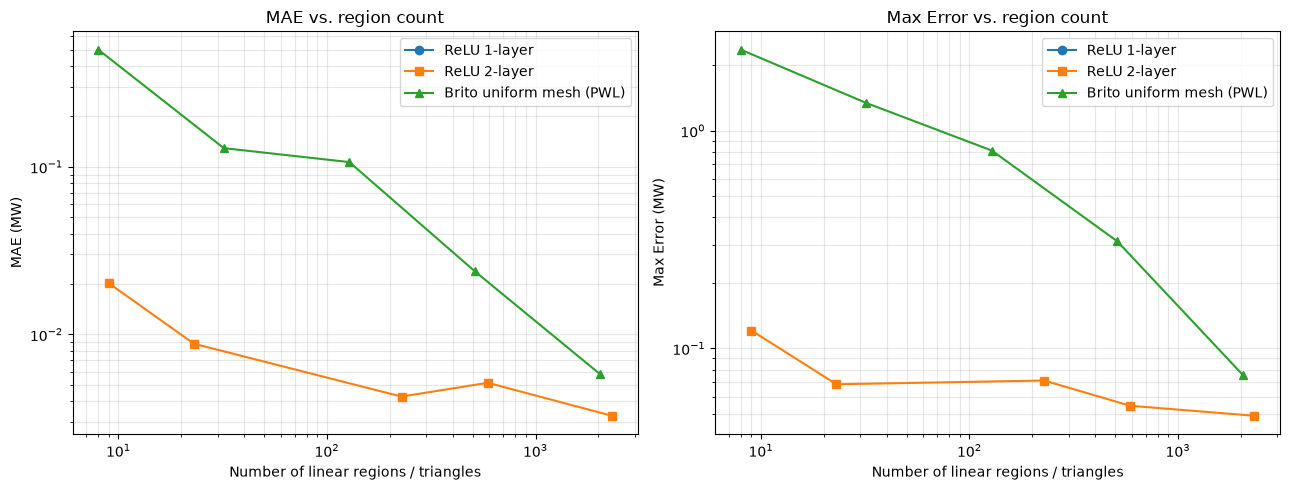


model                   regions    MAE (MW)  MaxErr (MW)
ReLU 2-layer [8, 8]              9      0.0202       0.1208
ReLU 2-layer [16, 16]           23      0.0088       0.0684
ReLU 2-layer [32, 32]          228      0.0043       0.0712
ReLU 2-layer [64, 64]          590      0.0051       0.0545
ReLU 2-layer [128, 128]       2323      0.0033       0.0491
mesh 3x3                       8      0.5008       2.3569
mesh 5x5                      32      0.1294       1.3403
mesh 9x9                     128      0.1068       0.8106
mesh 17x17                    512      0.0238       0.3101
mesh 33x33                   2048      0.0058       0.0755


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ei, name in zip(axes, (3, 4), ("MAE", "Max Error")):
    # ReLU 单层 / 双层
    for label, marker in (("1-layer", "o"), ("2-layer", "s")):
        rs = [(r[2], r[ei]) for r in relu_results if r[0] == label]
        rs.sort()
        ax.plot([r[0] for r in rs], [r[1] for r in rs],
                marker=marker, label=f"ReLU {label}")
    # Brito mesh
    ms = [(m[1], m[ei - 1]) for m in mesh_results]
    ax.plot([m[0] for m in ms], [m[1] for m in ms],
            marker="^", label="Brito uniform mesh (PWL)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Number of linear regions / triangles")
    ax.set_ylabel(f"{name} (MW)")
    ax.set_title(f"{name} vs. region count")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 汇总表
print(f"\n{'model':<22}{'regions':>9}{'MAE (MW)':>12}{'MaxErr (MW)':>13}")
for label, hidden, R, mae, mx in relu_results:
    print(f"ReLU {label} {str(hidden):<12}{R:>9}{mae:>12.4f}{mx:>13.4f}")
for K, n_tri, mae, mx in mesh_results:
    print(f"mesh {K}x{K:<16}{n_tri:>9}{mae:>12.4f}{mx:>13.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ei, name in zip(axes, (3, 4), ("MAE", "Max Error")):
    for label, marker in (("1-layer", "o"), ("2-layer", "s")):
        rs = sorted((r[2], r[ei]) for r in relu_results if r[0] == label)
        if rs:
            ax.plot([r[0] for r in rs], [r[1] for r in rs],
                    marker=marker, label=f"ReLU {label}")
    ms = [(m[1], m[ei - 1]) for m in mesh_results]
    ax.plot([m[0] for m in ms], [m[1] for m in ms],
            marker="^", label="Uniform mesh (interp)")
    am = [(a[0], a[ei - 2]) for a in automesh_results]
    ax.plot([a[0] for a in am], [a[1] for a in am],
            marker="v", label="AutoMesh (adaptive J1)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Number of linear regions / pieces")
    ax.set_ylabel(f"{name} (MW)")
    ax.set_title(f"{name} vs. region count")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

plt.tight_layout(); plt.show()

print(f"\n{'model':<24}{'regions':>9}{'MAE (MW)':>12}{'MaxErr (MW)':>13}")
for label, hidden, R, mae, mx in relu_results:
    print(f"ReLU {label} {str(hidden):<14}{R:>9}{mae:>12.4f}{mx:>13.4f}")
for K, n_tri, mae, mx in mesh_results:
    print(f"uniform {K}x{K:<15}{n_tri:>9}{mae:>12.4f}{mx:>13.4f}")
for n, mae, mx in automesh_results:
    print(f"automesh{'':<16}{n:>9}{mae:>12.4f}{mx:>13.4f}")